### Environment Setup and Library Imports

In [1]:
from IPython.display import clear_output

!pip install dask[dataframe] catboost

clear_output()


In [2]:
from IPython.display import clear_output
%pip install imbalanced-learn

%pip install kagglehub catboost xgboost tqdm imbalanced-learn -q

clear_output()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from tqdm import tqdm

%matplotlib inline

### Dataset Acquisition
Fetching the Air Quality and Pollution Assessment dataset from Kaggle.

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mujtabamatin/air-quality-and-pollution-assessment")

print("Path to dataset files:", path)

100%|██████████| 84.1k/84.1k [00:00<00:00, 22.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mujtabamatin/air-quality-and-pollution-assessment/versions/2


In [5]:
csv_path = os.path.join(path, "updated_pollution_dataset.csv")

df = pd.read_csv(csv_path)

df.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


### Exploratory Data Analysis (EDA)
Performing descriptive statistics and checking for imbalances, duplicates, and outliers.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


In [7]:
df.describe()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


#### Outlier Detection
Detecting outliers using the Interquartile Range (IQR) method.

In [8]:
columns_to_check = ['Temperature', 'Humidity', 'PM2.5', 'PM10','Population_Density']

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

for col in columns_to_check:
    outliers_df = detect_outliers_iqr(df, col)
    print(f"--- Outlier Analysis: {col} ---")
    if outliers_df.empty:
        print("No outliers detected.")
    else:
        print(f"Found {len(outliers_df)} outliers.")
        print(outliers_df)
    print("-" * 40 + "\n")

--- Outlier Analysis: Temperature ---
Found 72 outliers.
      Temperature  Humidity  PM2.5   PM10   NO2   SO2    CO  \
29           52.5      83.9   67.5   91.2  31.6  34.6  2.31   
55           48.1      94.1    4.2   19.0  23.7   6.0  1.57   
67           58.6      66.0   44.0   54.0  44.3  22.7  3.09   
106          49.6      87.5   81.9   87.0  40.4  18.4  2.14   
249          50.9      79.9   22.5   52.0  38.2   9.0  2.65   
...           ...       ...    ...    ...   ...   ...   ...   
4664         49.1      93.0   57.2   85.2  36.9  22.3  2.77   
4814         52.6      91.3  150.5  159.0  36.8   6.3  2.71   
4892         50.2      69.1    0.4   24.1  41.5  21.9  2.82   
4938         48.8      95.8    9.8   28.0  36.0  33.7  2.59   
4945         47.5      84.9   55.8   65.9  39.4  17.8  2.57   

      Proximity_to_Industrial_Areas  Population_Density Air Quality  
29                              2.9                 785   Hazardous  
55                              6.0           

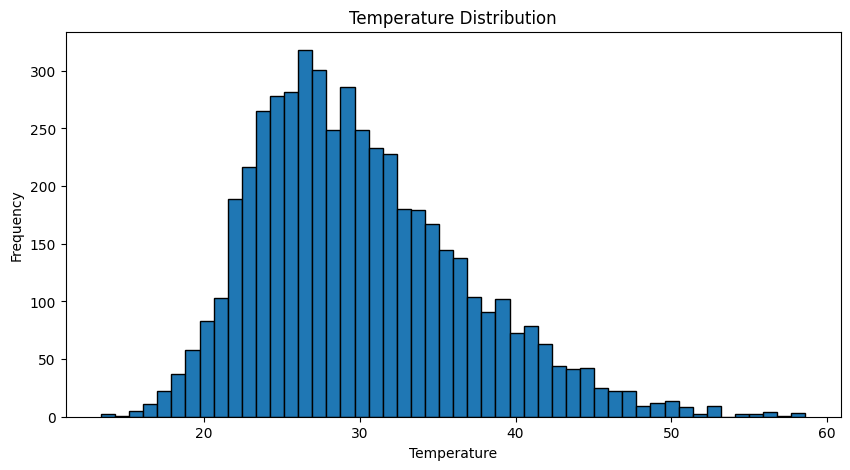

In [9]:
#Draw columns to see How the outliers looks like
plt.figure(figsize=(10, 5))
plt.hist(df['Temperature'].dropna(), bins=50, edgecolor='black')
plt.title('Temperature Distribution')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.show()

#### Class Distribution Analysis
Identifying class imbalances in the target variable to determine if resampling or stratified validation is necessary.

Target Distribution:


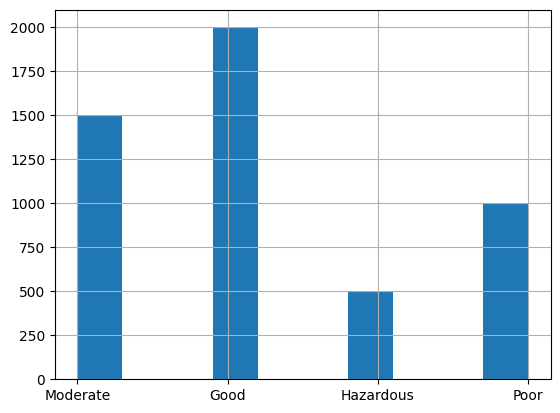

In [10]:
def check_target_imbalance(df, target_column):
  print("Target Distribution:")
  df[target_column].hist()
  plt.show()

check_target_imbalance(df, "Air Quality")

#### Duplicate Detection and Removal

In [11]:
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates_count}")

if duplicates_count > 0:
    df.drop_duplicates(inplace=True)

print("Final row count:", len(df))

Number of duplicate rows: 0
Final row count: 5000


In [12]:
df.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


### Data Preprocessing and Partitioning
Splitting data using stratification to preserve class ratios in training and test sets.

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop('Air Quality', axis=1)
y = df['Air Quality']

# Stratified split to handle imbalanced target classes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4000, 9)
X_test shape: (1000, 9)


### Label Encoding
Mapping ordinal categories to numerical values.

In [14]:
quality_mapping = {
    'Good': 0,
    'Moderate': 1,
    'Poor': 2,
    'Hazardous': 3
}

y_train_encoded = y_train.map(quality_mapping)
y_test_encoded = y_test.map(quality_mapping)

In [15]:
# Examine descriptive statistics for training data only
# Notice how (min) and (max) values vary between columns
print(X_train.describe().round(2))

       Temperature  Humidity    PM2.5     PM10      NO2      SO2       CO  \
count      4000.00   4000.00  4000.00  4000.00  4000.00  4000.00  4000.00   
mean         30.01     70.09    20.03    30.09    26.41     9.94     1.50   
std           6.70     15.90    24.45    27.32     8.88     6.70     0.55   
min          13.40     36.00     0.00     0.10     8.50    -6.20     0.65   
25%          25.10     58.30     4.60    12.30    20.20     5.10     1.03   
50%          29.00     69.80    12.00    21.60    25.20     7.90     1.42   
75%          33.90     80.30    25.80    37.70    31.90    13.60     1.85   
max          58.60    128.10   295.00   315.80    64.90    44.90     3.72   

       Proximity_to_Industrial_Areas  Population_Density  
count                        4000.00              4000.0  
mean                            8.43               498.7  
std                             3.61               152.1  
min                             2.50               188.0  
25%        

### Feature Scaling
Applying RobustScaler to minimize the influence of outliers identified during EDA.

In [16]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

# Fit on training data only to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("--- Scaled Features Preview ---")
print(X_train_scaled_df.head().round(3))

--- Scaled Features Preview ---
      Temperature  Humidity  PM2.5   PM10    NO2    SO2     CO  \
408        -0.523    -0.986  0.132 -0.071 -0.060 -0.424 -0.671   
3420       -0.364    -0.205  0.736  0.445 -0.855 -0.082 -0.366   
1073        0.080    -0.718 -0.557 -0.551 -0.821 -0.412 -0.598   
169         0.057     0.614 -0.344  0.043  0.915  0.800  1.890   
3881        0.568     0.245  1.604  1.402  1.735  0.882  2.341   

      Proximity_to_Industrial_Areas  Population_Density  
408                           0.719              -0.528  
3420                          0.439              -0.959  
1073                          0.509              -0.436  
169                          -0.474               0.619  
3881                         -0.281               0.482  


In [17]:
# Final verification of data dimensions and distributions post-scaling
print("X_train dimensions:", X_train.shape)
print("X_test dimensions:", X_test.shape)
print("-" * 50)
display(X_train.describe().round(3))

X_train dimensions: (4000, 9)
X_test dimensions: (1000, 9)
--------------------------------------------------


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000
mean,30.010,70.088,20.030,30.095,26.413,9.938,1.502,8.429,498.697
std,6.696,15.903,24.455,27.319,8.884,6.698,0.547,3.606,152.099
min,13.400,36.000,0.000,0.100,8.500,-6.200,0.650,2.500,188.000
25%,25.100,58.300,4.600,12.300,20.200,5.100,1.030,5.400,383.000
50%,29.000,69.800,12.000,21.600,25.200,7.900,1.420,7.900,496.000
75%,33.900,80.300,25.800,37.700,31.900,13.600,1.850,11.100,601.000
max,58.600,128.100,295.000,315.800,64.900,44.900,3.720,25.200,957.000


### Model Development and Evaluation
Using CatBoost with Stratified K-Fold Cross-Validation and SMOTE. SMOTE is applied within each fold to balance the training set without causing leakage into the validation set.

In [18]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
from imblearn.over_sampling import SMOTE

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_model = None
best_accuracy = 0
best_fold = 0
fold_number = 1

# Convert to numpy array for compatibility with indexing during cross-validation
y_train_array = np.array(y_train_encoded)

for train_index, val_index in skf.split(X_train_scaled, y_train_array):
    X_fold_train, X_fold_val = X_train_scaled[train_index], X_train_scaled[val_index]
    y_fold_train, y_fold_val = y_train_array[train_index], y_train_array[val_index]

    # Address class imbalance within the training fold only
    smote = SMOTE(random_state=42)
    X_fold_train_balanced, y_fold_train_balanced = smote.fit_resample(X_fold_train, y_fold_train)

    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.1,
        depth=6,
        loss_function='MultiClass',
        verbose=False,
        random_state=42
    )

    model.fit(X_fold_train_balanced, y_fold_train_balanced)

    y_pred_val = model.predict(X_fold_val)
    fold_accuracy = accuracy_score(y_fold_val, y_pred_val)

    print(f"Fold {fold_number} - accuracy: {fold_accuracy:.4f}")

    if fold_accuracy > best_accuracy:
        best_accuracy = fold_accuracy
        best_model = model
        best_fold = fold_number

    fold_number += 1

print(f"\nBest Fold: {best_fold} | Best Accuracy: {best_accuracy:.4f}")

# Model evaluation on the held-out test set
y_test_pred = best_model.predict(X_test_scaled)
print(f"\nTest Set Accuracy: {accuracy_score(y_test_encoded, y_test_pred):.4f}")
target_names = ['Good', 'Moderate', 'Poor', 'Hazardous']
print(classification_report(y_test_encoded, y_test_pred, target_names=target_names))

Fold 1 - accuracy: 0.9563
Fold 2 - accuracy: 0.9500
Fold 3 - accuracy: 0.9500
Fold 4 - accuracy: 0.9487
Fold 5 - accuracy: 0.9563

Best Fold: 1 | Best Accuracy: 0.9563

Test Set Accuracy: 0.9490
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       400
    Moderate       0.96      0.97      0.97       300
        Poor       0.88      0.87      0.87       200
   Hazardous       0.85      0.85      0.85       100

    accuracy                           0.95      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.95      0.95      0.95      1000

